# Ocean Modelling: Exercise 12: The Diffusion Equation
Numerical solution of the 1D diffusion problem
$$ \frac{\partial N}{\partial t} =  k \frac{\partial^2 N}{\partial x^2}$$ 
using an explicit scheme

$N(x,t)$ represents the evolution of the dissolved nitrogen (DN) concentration along the estuary over time

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
# constants
SECPERDAY = 86400
M2KM = 1000

## User Defined Parameters

In [8]:
# problem parameters
kappa=1.0e3   # Eddy diffusion coefficient [m2 s-1]
dx=500         # X resolution [m]
dt=100         # time step [s]
t0=0.          # initial time
tmax=0.12      # duration of simulation [days]
xmax=10.0e3    # length of the basin [m]

# parameters of the initial DIN spillage
N0 = 20.       # baseline concentration [mmol/m3]
sigma = 1000.  # width [m]
A = 100.       # amplitude [mmol/m3]

## Initial Function and Grid Specifications
The initial shape of the temperature distribution is a Gaussian peak function

In [9]:
# spatial shape of the initial DIN concentration
def Gaussian(x):
    y = N0+A*np.exp(-(x/sigma)**2)
    return y

The resulting space-time grid depends on the parameters above. The non-dimensional Courant number must be smaller than 0.5 for conditional stability.

In [10]:
# time axis
NT = int(np.floor(tmax*86400/dt))+1  # number of steps (starts from 0)
# X axis (centred at 0)
x = np.arange(-xmax,xmax,dx)
IM = len(x)             # number of grid points
N = np.zeros([IM,NT])   # the array holding the numerical solution 
print('Grid steps : ',IM)
print('Number of time steps : ',NT)
print('Timestep = ',dt,' s')
print('Max numerical diffusion DX^2/DT = ',dx**2/dt,' m2/s')
print('Physical diffusion = ',kappa,' m2/s')
print('Courant number (diffusion) = ',kappa*dt/(dx**2))

Grid steps :  40
Number of time steps :  104
Timestep =  100  s
Max numerical diffusion DX^2/DT =  2500.0  m2/s
Physical diffusion =  1000.0  m2/s
Courant number (diffusion) =  0.4


## Numerical Solution
Note that this code stores the solution at all times in array N for educational purposes. This allows to plot the solution at the different time steps and see how it evolves.

*This method is very inefficient for any application because it uses a lot of memory. In modern computer codes only a few time records are hold in memory. The instantaneous solution is often temporarely stored for computing time averages and then discarded.*

This part of the code is the topic of one question found in the lecture notes.

In [11]:
# compute the numerical solution using a time loop over the number of time steps
N[:,0] = Gaussian(x)    # initial condition

for n in range(NT-1):
    # Question 2
    N[0,n+1]  = N[1,n]
    N[-1,n+1] = N[-2,n]
    # discretization of the second derivative
    rhs = kappa*(N[:-2,n]-2*N[1:-1,n]+N[2:,n])/(dx**2)
    N[1:-1,n+1] = N[1:-1,n] + rhs*dt    

## Plot the Result Using a Matplotlib Animation
The animation below displays the evolution of the solution and compares it with the initial condition

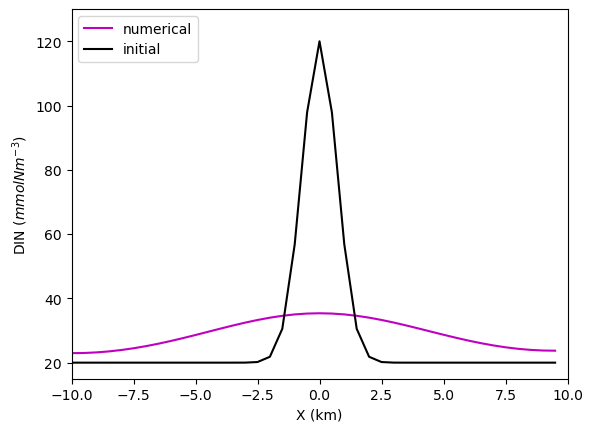

In [12]:
fig, ax = plt.subplots()
# set the axis limits
plt.axis([-xmax/M2KM, xmax/M2KM, N0-5, N0+A+10])
# first plot the initial condition and set the line attributes
sol, = ax.plot(x/M2KM, N[:,0],'m',label='numerical')
line, = ax.plot(x/M2KM, Gaussian(x),'k',label='initial')
ax.set_xlabel('X (km)')
ax.set_ylabel('DIN ($mmol N m^{-3}$)')
plt.legend(loc='upper left')

def animate(i):
    sol.set_ydata(N[:,i])  # update the numerical solution
    return sol,

# create the animation and loop (interval is in ms)
ani = animation.FuncAnimation(
    fig, animate, interval=dt, blit=True, frames=NT, repeat=True)

# display the animation as a javascript object embedded in the notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

### The numerical solution is similar to Ex. 11 implemented in the notebook diffusion.ipynb. Familiarize yourself with the code and answer the following questions in a modified version of the notebook:
#### 1. Study the numerical solution. Why does the flattening of the peak slow down with time?
The change in diffusion is proportional to the gradient. When diffusion of N takes place over time, the spatial gradient of N flattens out (equlibrates) so that causes diffusion to slow down because there is less of a steep gradient to encourage the diffusion. When the concnetration is uniform across space, there will be no more diffusion.

#### 2. Look for the comment #Question 2 in the code. This is a different type of boundary conditions called Neumann Conditions (not to be mistaken with von Neumann). How would you describe them? Change the boundary conditions to the ones used in the advection equation (Dirichlet Boundary Conditions, where the value at the boundary is prescribed). Run this code and compare it with the original: why do you think the Neumann Boundary Conditions are more realistic?
These lines set the Neumann Boundary Conditions at each time step. Instead of fixing the values along the boundaries (like Dirichlet), the gradient is fixed to zero at the boundaries. N[0, n+1] = N[1, n] sets the left boundary (x = -xmax) equal to its nearest interior neighbour so the slope between them is zero. N[-1, n+1] = N[-2, n] does the same thing for right boundary (x = +xmax). This means that the boundaries have the same values as the interior so that there is no gradients between the boundary and the interior. This prevents any diffusion across the boundaries so the amount of N is conserved within its domain. 

In the advection problem, the Dirichlet Boundary Conditions (N = N0) make sense because the flow was carrying the signal out of the domain through the boundary. In this case, the diffusion is occuring within a closed basin so there is no diffusion carrying N out of the basin. The Neumann Conditions correctly represent solid walls (the boundaries) that the N cannot cross. The Dirichlet Boundary Conditions would incorrectly remove N at the boundaries (the boundaries would be absorbing N) so the total concentration is not conserved which is unrealistic.

This is seen in the graphs where for the Neumann Conditions, the concentration after diffusion remains does not ever reach the intial concentration at the boundaries. However, when using Dirichlet Conditions, the final concentrations at the boundaries are equal to the inital concentrations because the boundaries remove N from the domain and allow N to pass through which would lower the final concentration during diffusion more than when Neumann Conditions are used. 

#### 3. The grid parameters determine the stability of the numerical solution and its evolution, based on the physical parameters. In this case, the key parameter is the eddy diffusivity coefficient, which indicates the turbulence of the fluid and how quickly it dissipates the signal. What happens if you double the diffusivity coefficient? [you can adjust the y-axis limits to see the behaviour better]. What would you do to fix it and why?
When K doubles, this increases the diffusion Courant Number and this exceeds the stability limit of C < 0.5 for the diffusion schemes used. The solution blows up as the oscillations grow but this has nothing to do with the physics.

In order to fix this, C must be brough back below 0.5 so that stability is maintained again. This can be done in 2 ways:
- Option 1 — halve dt 
- Option 2 — increase dx
Option 1 (halving dt) is better since increasig dx makes the grid coarser and the solution less accurate. The stabiliyy would still improve, but at the cost of the resolution. If dt is halved, this means that there are more timesteps (more computation), but the spatial accuracy is kept the same. When dt is halved, this will halve the Courant Number so the scheme will be stable again so the diffusion can be represented correctly again.

QUESTION 1 — Standard run (Neumann BC, κ=1000 m²/s)
Courant number (diffusion) = 0.4

QUESTION 2 — Neumann vs Dirichlet boundary conditions


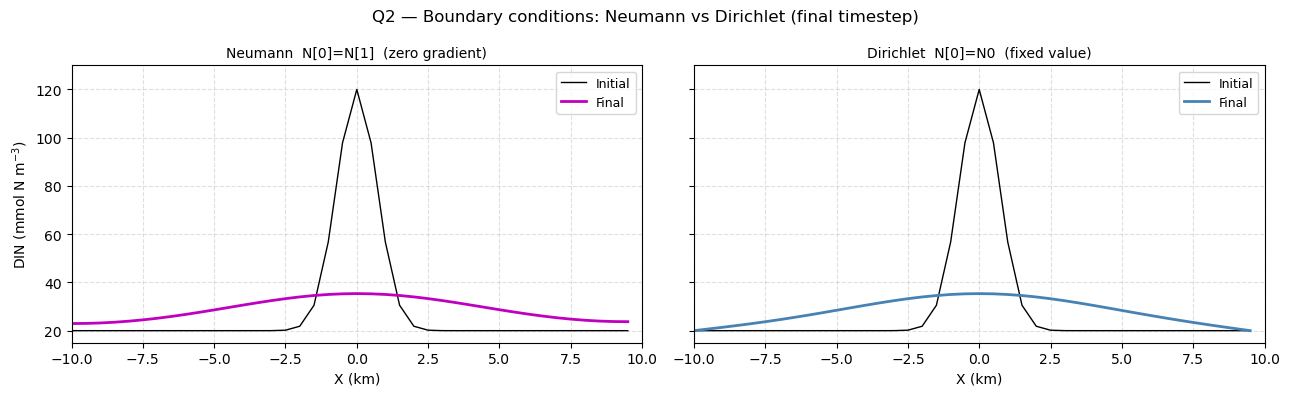


QUESTION 3 — Doubling diffusivity κ
Courant number with κ=2000.0: 0.800
Stability requires C ≤ 0.5 — halving dt fixes it
Courant number with κ=2000.0, dt=50s: 0.400


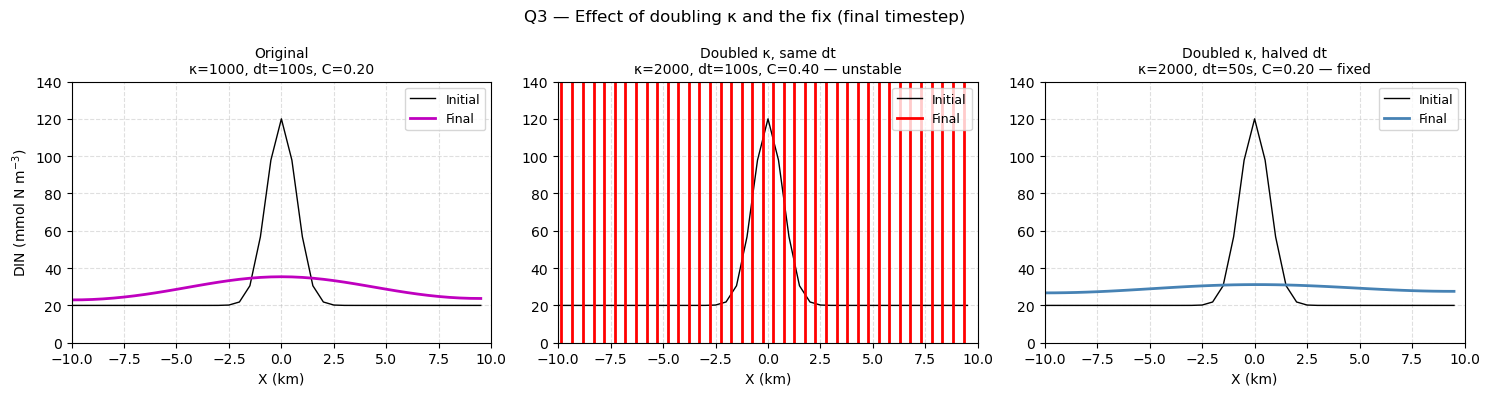

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# constants
SECPERDAY = 86400
M2KM = 1000

# base parameters 
kappa = 1.0e3
dx    = 500
dt    = 100
t0    = 0.
tmax  = 0.12
xmax  = 10.0e3
N0    = 20.
sigma = 1000.
A     = 100.

def Gaussian(x):
    return N0 + A * np.exp(-(x / sigma) ** 2)

def run_diffusion(kappa=1.0e3, dx=500, dt=100, bc='neumann'):

    NT = int(np.floor(tmax * SECPERDAY / dt)) + 1
    x  = np.arange(-xmax, xmax, dx)
    N  = np.zeros([len(x), NT])
    N[:, 0] = Gaussian(x)

    for n in range(NT - 1):
        if bc == 'neumann':
            N[0,  n+1] = N[1,  n]   # zero-gradient left
            N[-1, n+1] = N[-2, n]   # zero-gradient right
        else:
            N[0,  n+1] = N0          # fixed value left
            N[-1, n+1] = N0          # fixed value right

        rhs = kappa * (N[:-2, n] - 2 * N[1:-1, n] + N[2:, n]) / dx**2
        N[1:-1, n+1] = N[1:-1, n] + rhs * dt

    return x, N, NT

def make_animation(x, N, NT, dt, title, ymin=None, ymax=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    ymin = ymin if ymin is not None else N0 - 5
    ymax = ymax if ymax is not None else N0 + A + 10
    ax.set_xlim(-xmax / M2KM, xmax / M2KM)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('X (km)')
    ax.set_ylabel('DIN (mmol N m$^{-3}$)')
    ax.set_title(title, fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.plot(x / M2KM, Gaussian(x), 'k', linewidth=1, label='Initial')
    sol, = ax.plot(x / M2KM, N[:, 0], 'm', linewidth=2, label='Numerical')
    ax.legend(loc='upper left')

    def animate(i):
        sol.set_ydata(N[:, i])
        return sol,

    ani = animation.FuncAnimation(
        fig, animate, interval=dt, blit=True, frames=NT, repeat=True)
    plt.close(fig)
    return HTML(ani.to_jshtml())
    
# =====================================================================
# QUESTION 1 — standard run; observe peak flattening slowing with time
# =====================================================================
print('='*60)
print('QUESTION 1 — Standard run (Neumann BC, κ=1000 m²/s)')
print('='*60)
print('Courant number (diffusion) =', kappa * dt / dx**2)
x, N, NT = run_diffusion()
q1 = make_animation(x, N, NT, dt,
    title='Q1 — Diffusion of DIN spill  (Neumann BC, κ=1000 m²/s)')
q1

# =====================================================================
# QUESTION 2 — Neumann vs Dirichlet boundary conditions
# =====================================================================
print()
print('='*60)
print('QUESTION 2 — Neumann vs Dirichlet boundary conditions')
print('='*60)

x, N_neu, NT = run_diffusion(bc='neumann')
x, N_dir, NT = run_diffusion(bc='dirichlet')

# side-by-side snapshot at final timestep
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
fig.suptitle('Q2 — Boundary conditions: Neumann vs Dirichlet (final timestep)', fontsize=12)

for ax, N_sol, label, color in zip(
        axes,
        [N_neu, N_dir],
        ['Neumann  N[0]=N[1]  (zero gradient)',
         'Dirichlet  N[0]=N0  (fixed value)'],
        ['m', 'steelblue']):
    ax.plot(x / M2KM, Gaussian(x),   'k',    linewidth=1,   label='Initial')
    ax.plot(x / M2KM, N_sol[:, -1],  color,  linewidth=2,   label='Final')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('X (km)')
    ax.set_xlim(-xmax / M2KM, xmax / M2KM)
    ax.set_ylim(N0 - 5, N0 + A + 10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)

axes[0].set_ylabel('DIN (mmol N m$^{-3}$)')
plt.tight_layout()
plt.show()

# =====================================================================
# QUESTION 3 — doubling kappa; fix by halving dt
# =====================================================================
print()
print('='*60)
print('QUESTION 3 — Doubling diffusivity κ')
print('='*60)

kappa_double = 2.0e3
print(f'Courant number with κ={kappa_double}: {kappa_double * dt / dx**2:.3f}')
print(f'Stability requires C ≤ 0.5 — halving dt fixes it')
print(f'Courant number with κ={kappa_double}, dt=50s: {kappa_double * 50 / dx**2:.3f}')

x, N_k2_unstable, NT1 = run_diffusion(kappa=kappa_double, dt=dt)
x, N_k2_fixed,    NT2 = run_diffusion(kappa=kappa_double, dt=50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Q3 — Effect of doubling κ and the fix (final timestep)', fontsize=12)

datasets = [
    (N,             NT,  dt,  kappa,        'Original\nκ=1000, dt=100s, C=0.20', 'm'),
    (N_k2_unstable, NT1, dt,  kappa_double, 'Doubled κ, same dt\nκ=2000, dt=100s, C=0.40 — unstable', 'red'),
    (N_k2_fixed,    NT2, 50,  kappa_double, 'Doubled κ, halved dt\nκ=2000, dt=50s, C=0.20 — fixed', 'steelblue'),]

for ax, (N_sol, nt, dtt, kap, label, color) in zip(axes, datasets):
    C = kap * dtt / dx**2
    ax.plot(x / M2KM, Gaussian(x),   'k',   linewidth=1, label='Initial')
    ax.plot(x / M2KM, N_sol[:, -1],  color, linewidth=2, label='Final')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('X (km)')
    ax.set_xlim(-xmax / M2KM, xmax / M2KM)
    ax.set_ylim(N0 - 20, N0 + A + 20)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)

axes[0].set_ylabel('DIN (mmol N m$^{-3}$)')
plt.tight_layout()
plt.show()